In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def transpune_matrice(A):
    randuri = len(A)
    coloane = len(A[0]) if randuri > 0 else 0
    return [[A[i][j] for i in range(randuri)] for j in range(coloane)]

def inmulteste_matrici(A, B):
    randuri_A = len(A)
    randuri_B = len(B)
    coloane_A = len(A[0]) if randuri_A > 0 else 0
    coloane_B = len(B[0]) if randuri_B > 0 else 0

    C = [[0.0 for _ in range(coloane_B)] for _ in range(randuri_A)]
    for i in range(randuri_A):
        for j in range(coloane_B):
            for k in range(coloane_A):
                C[i][j] += A[i][k] * B[k][j]
    return C

def inverseaza_matrice(A):
    n = len(A)
    aug = []
    for i in range(n):
        rand = list(A[i])
        identitate = [1.0 if j == i else 0.0 for j in range(n)]
        aug.append(rand + identitate)
    
    for i in range(n):
        pivot = aug[i][i]
        if pivot == 0:
            raise ValueError("Matrix is singular and cannot be inverted")
        for j in range(n * 2):
            aug[i][j] /= pivot
        for j in range(n):
            if j != i:
                factor = aug[j][i]
                for k in range(n * 2):
                    aug[j][k] -= factor * aug[i][k]
    return [row[n:] for row in aug]

def manual(X_sir, Y_sir):
    X = X_sir.tolist() if hasattr(X_sir, 'tolist') else X_sir
    Y = Y_sir.tolist() if hasattr(Y_sir, 'tolist') else Y_sir

    X_mat = []

    if isinstance (X[0], list):
        for rand in X:
            X_mat.append(rand + [1.0])
    else:
        for val in X:
            X_mat.append([val, 1.0])
    
    Y_mat = [[val] for val in Y]

    X_T = transpune_matrice(X_mat)
    X_T_X = inmulteste_matrici(X_T, X_mat)
    Inversa = inverseaza_matrice(X_T_X)
    X_T_Y = inmulteste_matrici(X_T, Y_mat)

    W_mat = inmulteste_matrici(Inversa, X_T_Y)

    return [w[0] for w in W_mat]

def medie_lista(v):
    return sum(v) / len(v) if len(v) > 0 else 0.0

def scade_vectori(v1, v2):
    return [v1[i] - v2[i] for i in range(len(v1))]

def inmulteste_vector_scalar(v, scalar):
    return [val * scalar for val in v]

def adauga_bias(X):
    return [rand + [1.0] for rand in X]

In [8]:
def normalizeaza_multi_manual(X):
    randuri = len(X)
    coloane = len(X[0])
    
    medii = []
    for j in range(coloane):
        suma = sum(X[i][j] for i in range(randuri))
        medii.append(suma / randuri)
        
    deviatii = []
    for j in range(coloane):
        suma_patrate = sum((X[i][j] - medii[j])**2 for i in range(randuri))
        stdev = (suma_patrate / randuri)**0.5
        deviatii.append(stdev if stdev != 0 else 1.0)
        
    X_norm = []
    for i in range(randuri):
        rand_nou = [(X[i][j] - medii[j]) / deviatii[j] for j in range(coloane)]
        X_norm.append(rand_nou)
        
    return X_norm, medii, deviatii

def antreneaza_batch_gd_universal_manual(X_raw, Y_raw, learning_rate=0.01, epoci=1000, usa_mae=False):
    X = X_raw.tolist() if hasattr(X_raw, 'tolist') else X_raw
    Y = Y_raw.tolist() if hasattr(Y_raw, 'tolist') else Y_raw
    
    n = len(Y)
    X_bias = [[1.0] + (rand if isinstance(rand, list) else [rand]) for rand in X]
    m = len(X_bias[0])

    W = [[0.0] for _ in range(m)]
    Y_mat = [[val] for val in Y]

    istoric_eroare = []
    for epoch in range(epoci):
        Y_pred = inmulteste_matrici(X_bias, W)
        
        eroare_mat = [[Y_pred[i][0] - Y_mat[i][0]] for i in range(n)]
        
        if usa_mae:
            err = sum(abs(e[0]) for e in eroare_mat) / n
            semn_eroare = [[(1.0 if e[0] > 0 else -1.0 if e[0] < 0 else 0.0)] for e in eroare_mat]
            X_T = transpune_matrice(X_bias)
            gradient_mat = inmulteste_matrici(X_T, semn_eroare)
            factor = 1.0 / n
        else:
            err = sum(e[0]**2 for e in eroare_mat) / n
            X_T = transpune_matrice(X_bias)
            gradient_mat = inmulteste_matrici(X_T, eroare_mat)
            factor = 2.0 / n
            
        istoric_eroare.append(err)
        
        for i in range(m):
            W[i][0] -= learning_rate * factor * gradient_mat[i][0]

    return [w[0] for w in W], istoric_eroare

Rezultat final: w = 0.9161194989879298, b = 5.354019346763286


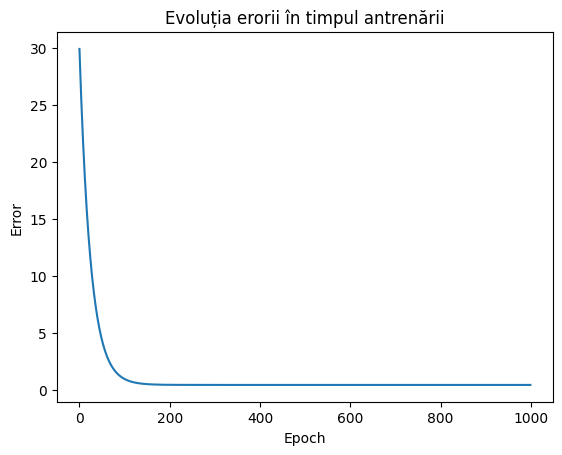

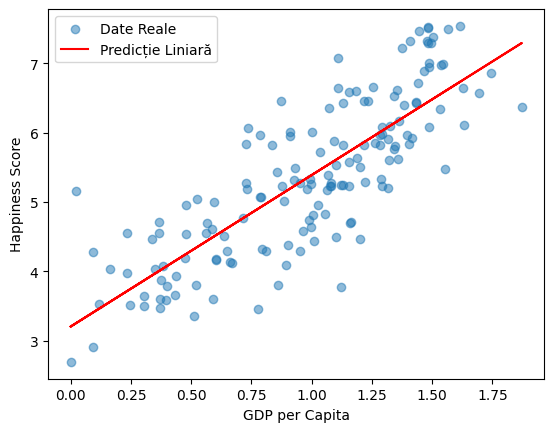

In [9]:
df = pd.read_csv("resources/2017.csv")
col_gdp = "Economy..GDP.per.Capita."
col_freedom = "Freedom"
col_happiness = "Happiness.Score"

X_raw = df[[col_gdp]].values.tolist()
Y = df[col_happiness].values.tolist()

X_norm, media_x, std_x = normalizeaza_multi_manual(X_raw)
W, istoric_eroare = antreneaza_batch_gd_universal_manual(X_norm, Y)

bias = W[0]
w_gdp = W[1]

print(f"Rezultat final: w = {w_gdp}, b = {bias}")

plt.plot(istoric_eroare)
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Evoluția erorii în timpul antrenării")
plt.show()

Y_final_pred = [bias + w_gdp * x[0] for x in X_norm]

X_plot = [x[0] for x in X_raw]

plt.scatter(X_plot, Y, alpha=0.5, label="Date Reale")
plt.plot(X_plot, Y_final_pred, color="red", label="Predicție Liniară")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.legend()
plt.show()


Rezultat final: W = [5.428903225806417, 0.8137179866387904, 0.35897350524421273]


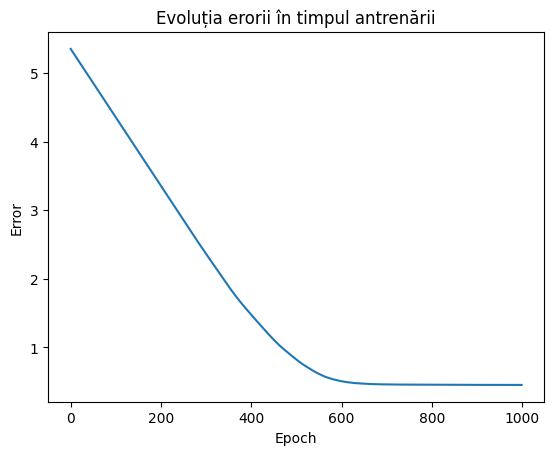

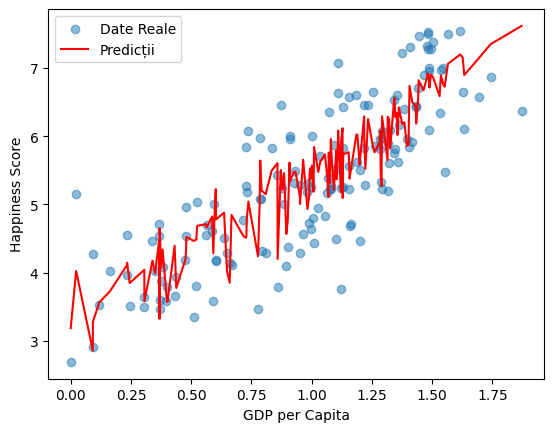

In [10]:
X_raw = df[[col_gdp, col_freedom]].values.tolist()
Y = df[col_happiness].values.tolist()

X_norm, media_x, std_x = normalizeaza_multi_manual(X_raw)

W, istoric_eroare = antreneaza_batch_gd_universal_manual(X_norm, Y, usa_mae=True)

print(f"Rezultat final: W = {W}")

plt.plot(istoric_eroare)
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Evoluția erorii în timpul antrenării")
plt.show()

Y_final_pred = [W[0] + W[1]*x[0] + W[2]*x[1] for x in X_norm]
X_plot_gdp = [x[0] for x in X_raw]

plt.scatter(X_plot_gdp, Y, alpha=0.5, label="Date Reale")

sorted_indices = np.argsort(X_plot_gdp)
X_plot_gdp_sorted = [X_plot_gdp[i] for i in sorted_indices]
Y_final_pred_sorted = [Y_final_pred[i] for i in sorted_indices]

plt.plot(X_plot_gdp_sorted, Y_final_pred_sorted, color="red", label="Predicții")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.legend()
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_tool = np.array(X_raw)
Y_tool = np.array(Y)

if X_tool.ndim == 1:
    X_tool = X_tool.reshape(-1, 1)

model = LinearRegression()
model.fit(X_tool, Y)
Y_pred_tool = model.predict(X_tool)

mse_tool = mean_squared_error(Y, Y_pred_tool)

print("MSE:", mse_tool)


MSE: 0.3250706060454289


In [12]:
import math
def sigmoid_manual(z):
    return 1 / (1 + math.exp(-z))

def antreneaza_logistic_batch_gd_manual(X_raw, Y_raw, learning_rate=0.1, epoci=2000):
    X = X_raw.tolist() if hasattr(X_raw, 'tolist') else X_raw
    Y = Y_raw.tolist() if hasattr(Y_raw, 'tolist') else Y_raw
    
    n = len(Y)
    X_bias = [rand + [1.0] for rand in X]
    m = len(X_bias[0])
    
    W = [[0.0] for _ in range(m)]
    Y_mat = [[val] for val in Y]
    
    istoric_eroare = []
    epsilon = 1e-15

    for epoch in range(epoci):
        Z = inmulteste_matrici(X_bias, W)
        
        Y_pred = [[sigmoid_manual(z[0])] for z in Z]
        
        suma_loss = 0
        for i in range(n):
            y_real = Y_mat[i][0]
            y_p = Y_pred[i][0]
            y_p = max(epsilon, min(1 - epsilon, y_p))
            suma_loss += -(y_real * math.log(y_p) + (1 - y_real) * math.log(1 - y_p))
        
        loss = suma_loss / n
        istoric_eroare.append(loss)

        eroare_mat = [[Y_pred[i][0] - Y_mat[i][0]] for i in range(n)]
        X_T = transpune_matrice(X_bias)
        gradient_mat = inmulteste_matrici(X_T, eroare_mat)
        
        for i in range(m):
            W[i][0] -= learning_rate * (1/n) * gradient_mat[i][0]
            
    return [w[0] for w in W], istoric_eroare

In [13]:

nume_coloane = ['ID', 'Diagnostic', 'Raza', 'Textura']

df_cancer = pd.read_csv('resources/wdbc.csv', header=None, names=nume_coloane, usecols = [0, 1, 2, 3])
df_cancer['Diagnostic'] = df_cancer['Diagnostic'].map({'M': 1, 'B': 0})

X_cancer_raw = df_cancer[['Raza', 'Textura']].values.tolist()
Y_cancer = df_cancer['Diagnostic'].values.tolist()

X_cancer_norm, media_x_cancer, std_x_cancer = normalizeaza_multi_manual(X_cancer_raw)

W_cancer, istoric_eroare_cancer = antreneaza_logistic_batch_gd_manual(X_cancer_norm, Y_cancer)
print(f"Results: {W_cancer}")

raza_noua = 18
textura_noua = 10
raza_norm = (raza_noua - media_x_cancer[0]) / std_x_cancer[0]
textura_norm = (textura_noua - media_x_cancer[1]) / std_x_cancer[1]

X_nou = W_cancer[0] * raza_norm + W_cancer[1] * textura_norm + W_cancer[2]
probabilitate = sigmoid_manual(X_nou)

verdict = "Maligna" if probabilitate >= 0.5 else "Benigna"

print(f"Verdict: {verdict}, Probabilitate: {probabilitate}")

Results: [3.633749615526774, 0.9254920390205029, -0.7056696216488404]
Verdict: Maligna, Probabilitate: 0.7842168475623121


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

log_reg = LogisticRegression()
log_reg.fit(X_cancer_raw, Y_cancer)

pacienta_noua = [[18, 10]]
verdict_tool = log_reg.predict(pacienta_noua)
probabilitate_tool = log_reg.predict_proba(pacienta_noua)

print(f"Verdict tool: {'Malign' if verdict_tool[0] == 1 else 'Benign'}")
print(f"Probabilitate tool: {probabilitate_tool[0][1]}")

Verdict tool: Malign
Probabilitate tool: 0.7908768927298516


In [15]:
nume_col_iris = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'specie']
df_iris = pd.read_csv('resources/iris.csv', header=None, names=nume_col_iris)

X_iris_raw = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values.tolist()
Y_iris = df_iris['specie'].values.tolist()

X_iris_norm, media_x_iris, std_x_iris = normalizeaza_multi_manual(X_iris_raw)
specii_unice = list(set(Y_iris))

In [16]:
modele_iris = {}
for specie in specii_unice:
    Y_binar = [1 if y == specie else 0 for y in Y_iris]
    W, _ = antreneaza_logistic_batch_gd_manual(X_iris_norm, Y_binar)
    modele_iris[specie] = W

In [17]:
floare_test = np.array([5.35, 3.85, 1.25, 0.4])

floare_test_norm = [(floare_test[i] - media_x_iris[i]) / std_x_iris[i] for i in range(len(floare_test))]

predictions = {}
for specie, W in modele_iris.items():
    z = 0
    for i in range(len(floare_test_norm)):
        z += W[i] * floare_test_norm[i]
    z += W[len(floare_test_norm)]
    predictions[specie] = sigmoid_manual(z)

verdict = max(predictions, key=predictions.get)
print(f"Verdict: {verdict}, Probabilitate: {predictions[verdict]}")


Verdict: Iris-setosa, Probabilitate: 0.9996060984182056


In [18]:
iris_model = LogisticRegression(max_iter= 1000)
iris_model.fit(X_iris_raw, Y_iris)

floare_test = [[5.35, 3.85, 1.25, 0.4]]
specie_tool = iris_model.predict(floare_test)

print(f"Specie tool: {specie_tool[0]}")

Specie tool: Iris-setosa


In [ ]:
import random

def impartire_date_manual(X, Y, procent_test=0.2):
    n = len(X)
    indices = list(range(n))
    random.shuffle(indices)
    
    limita = int(n * (1 - procent_test))
    
    idx_train = indices[:limita]
    idx_test = indices[limita:]
    
    X_train = [X[i] for i in idx_train]
    Y_train = [Y[i] for i in idx_train]
    X_test = [X[i] for i in idx_test]
    Y_test = [Y[i] for i in idx_test]
    
    return X_train, Y_train, X_test, Y_test


X_train, Y_train, X_test, Y_test = impartire_date_manual(X_norm, Y)
W_final, istoric = antreneaza_batch_gd_universal_manual(X_train, Y_train, learning_rate=0.1)
erori_test = []

for i in range(len(X_test)):
    predicitie = W_final[0]
    for j in range(len(X_test[i])):
        predicitie += W_final[j+1] * X_test[i][j]
    
    erori_test.append((predicitie - Y_test[i])**2)

mse_test = sum(erori_test) / len(erori_test)

print(f"MSE Antrenament: {istoric[-1]}")
print(f"MSE Test: {mse_test}")

In [ ]:
def evalueaza_prag(W, X_test, Y_test, prag):
    X_test_bias = np.column_stack((np.ones(X_test.shape[0]), X_test))

    probabilitati = sigmoid_manual(np.dot(X_test_bias, W))
    predictii = (probabilitati >= prag).astype(int)

    acuratete = np.mean(predictii == Y_test)
    fals_negativ = np.sum((predictii == 0) & (Y_test == 1))
    return acuratete, fals_negativ

for p in [0.2, 0.5, 0.8]:
    acc, fn = evalueaza_prag(W_cancer, X_cancer_norm, Y_cancer, p)
    print(f"Prag: {p}, Acuratete: {acc}, Cancere ratate: {fn}")



Prag: 0.2, Acuratete: 0.37258347978910367, Cancere ratate: 0
Prag: 0.5, Acuratete: 0.37258347978910367, Cancere ratate: 0
Prag: 0.8, Acuratete: 0.3866432337434095, Cancere ratate: 1
